# Plots for 2026 KPF Operational Review

The plots bleow are being made for the KPF Operational Review in January, 2026.  The code is posted to show the methods and to develop additional plots.

In [1]:
import os, re
from modules.quicklook.src.analyze_time_series import AnalyzeTimeSeries
import operator
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np
import time
from datetime import datetime, timedelta, timezone, date
from astropy.table import Table
import pandas as pd
%matplotlib inline

Update this configuration parameter to set the output directory for plots.

In [2]:
plot_dir = '/code/KPF-Pipeline/AWH_notebooks/report_plots/'

In [3]:
myTS = AnalyzeTimeSeries(backend='psql')

INFO: Starting AnalyzeTimeSeries
INFO: Starting KPF_TSDB
INFO: Jupyter Notebook environment detected.
INFO: Base data directory: /data/L0
INFO: Backend: psql
INFO: Table prefix: tsdb_
INFO: PSQL server: 127.0.0.1
INFO: PSQL username: timeseriesdba
INFO: PSQL user role: admin
INFO: Metadata table exists.
INFO: Metadata table read.
INFO: Data tables exist.


## Time Series Plots

INFO: Plotting from config: /code/KPF-Pipeline/static/tsdb_plot_configs/CCDs/ccd_pressure.yaml


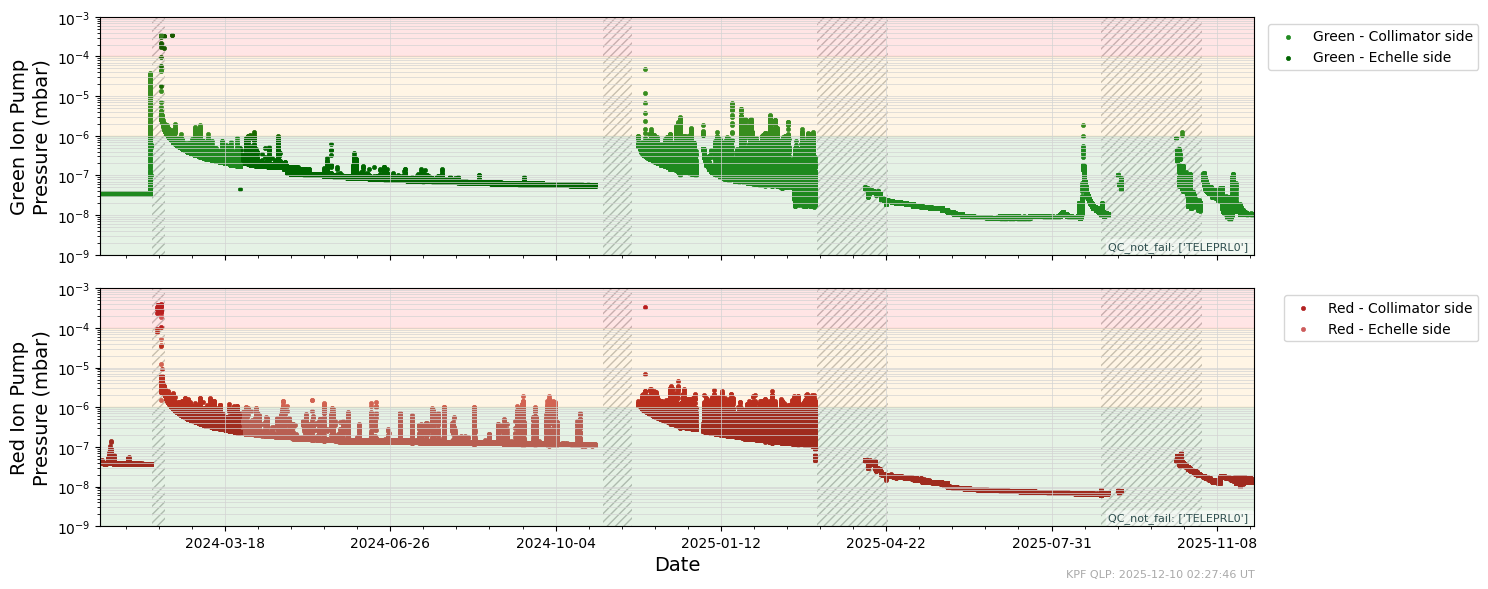

INFO: Plotting from config: /code/KPF-Pipeline/static/tsdb_plot_configs/CCDs/ccd_pressure.yaml


In [4]:
start_date = datetime(2022, 11, 9)
end_date = datetime(2026, 1, 1)

fig_path = f'{plot_dir}/ccd_pressure_time_series.png'
myTS.plot_time_series_multipanel('ccd_pressure', start_date=start_date, end_date=end_date, show_plot=True, clean=True)
myTS.plot_time_series_multipanel('ccd_pressure', start_date=start_date, end_date=end_date, fig_path=fig_path, clean=True)

INFO: Plotting from config: /code/KPF-Pipeline/static/tsdb_plot_configs/DRP/drptag.yaml


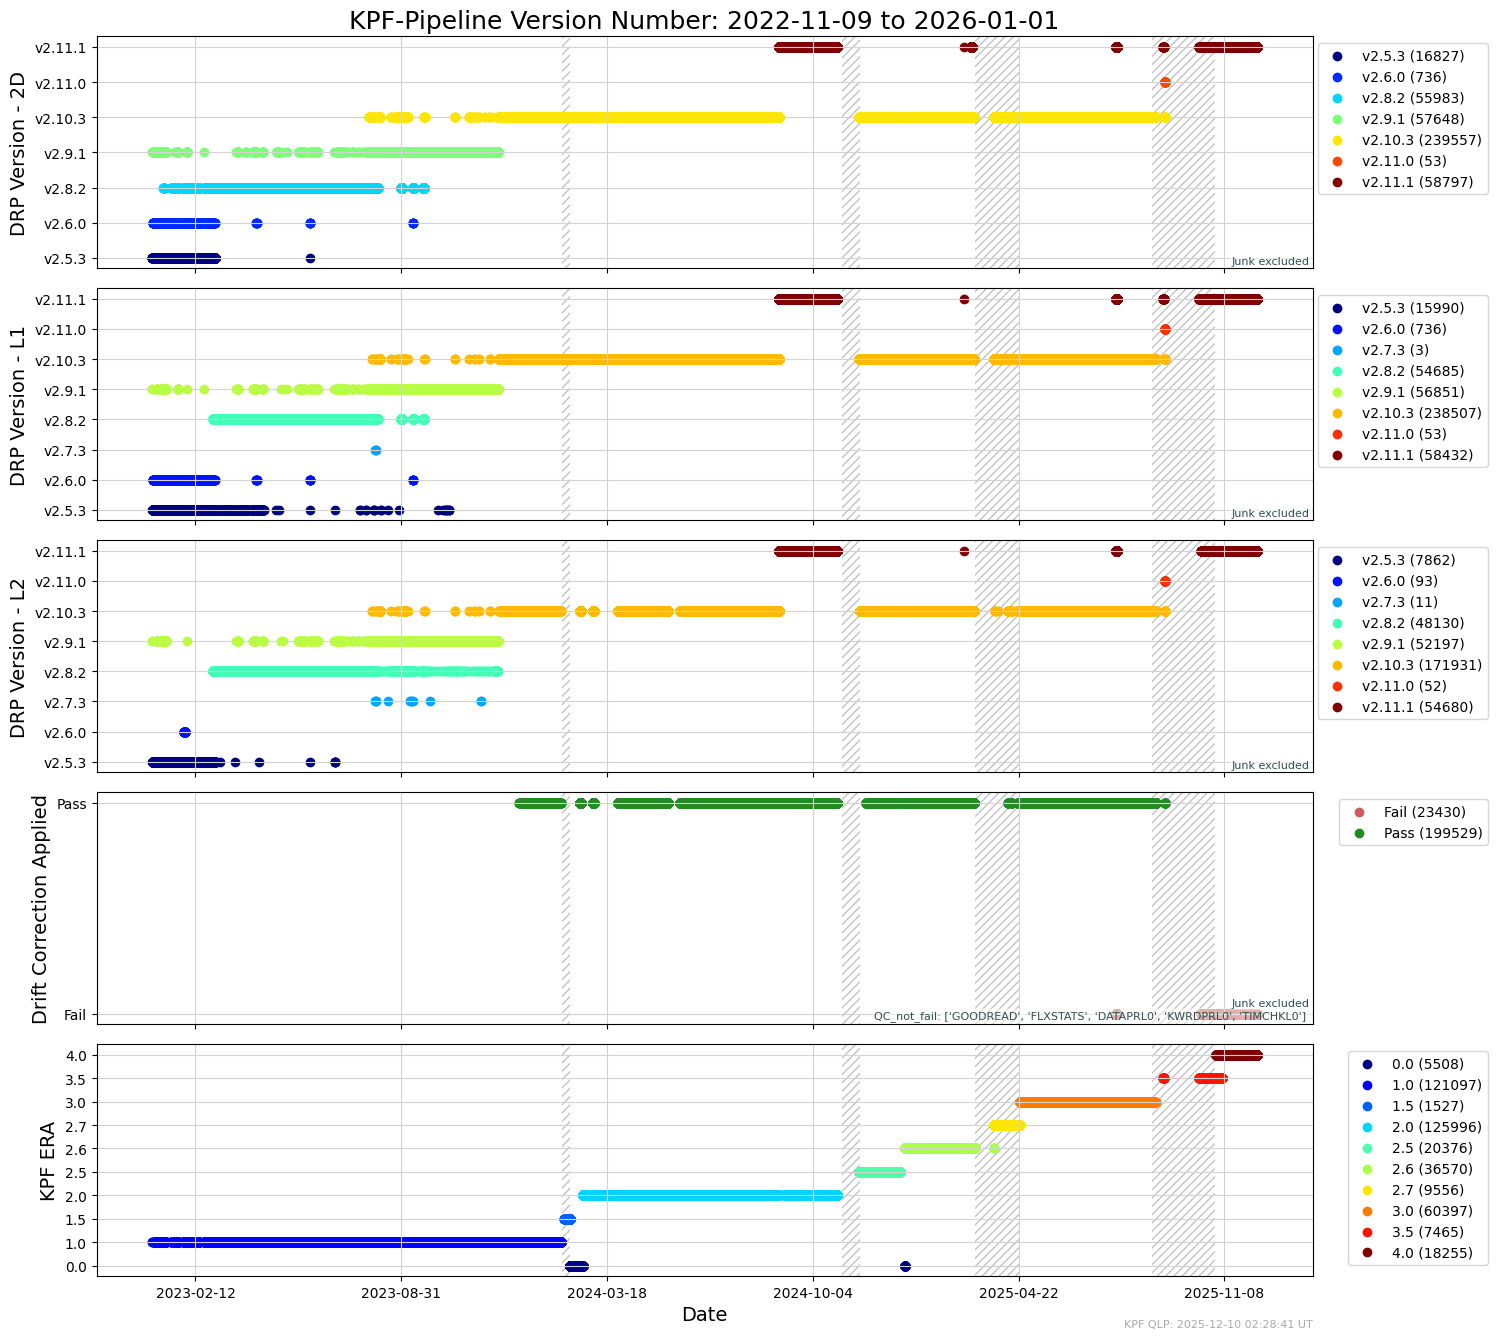

INFO: Plotting from config: /code/KPF-Pipeline/static/tsdb_plot_configs/DRP/drptag.yaml


In [5]:
start_date = datetime(2022, 11, 9)
end_date = datetime(2026, 1, 1)

fig_path = f'{plot_dir}/ccd_drp_tag.png'
myTS.plot_time_series_multipanel('drptag', start_date=start_date, end_date=end_date, show_plot=True, clean=True)
myTS.plot_time_series_multipanel('drptag', start_date=start_date, end_date=end_date, fig_path=fig_path, clean=True)

## Performance by Date Plots

### Temperature Plots

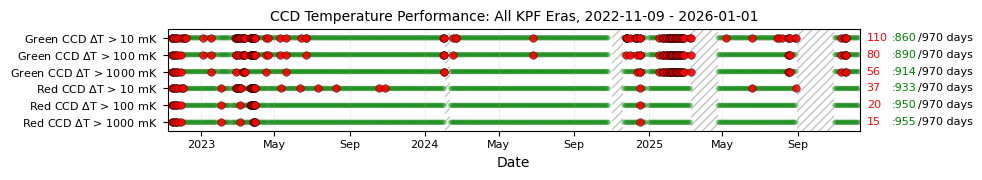

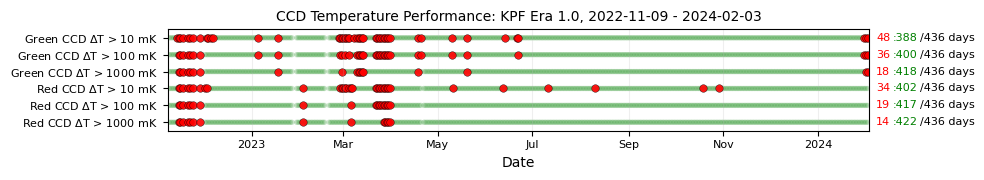

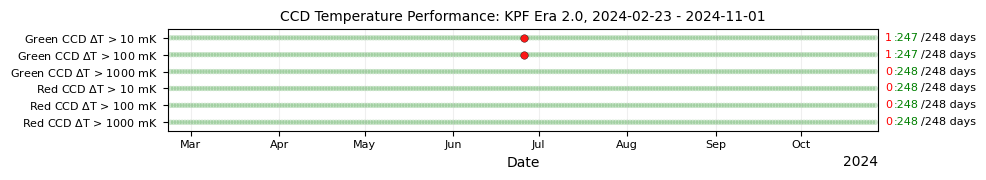

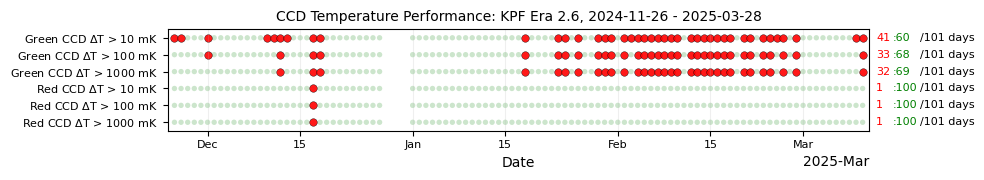

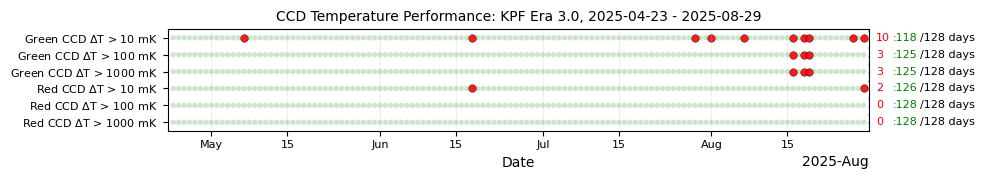

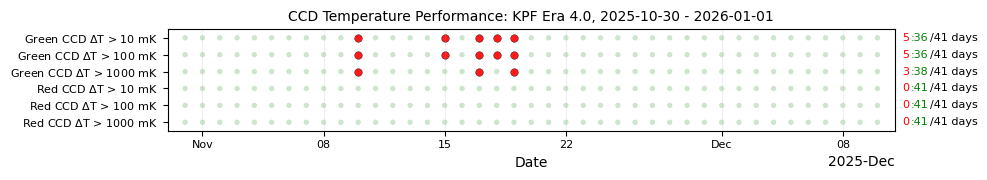

In [7]:
date_ranges = [
    (datetime(2022, 11,  9),  datetime(2026,  1,  1), 'All KPF Eras', 'kpfera_all'),
    (datetime(2022, 11,  9),  datetime(2024,  2,  3), 'KPF Era 1.0', 'kpfera_1_0'),
    (datetime(2024,  2, 23),  datetime(2024, 11,  1), 'KPF Era 2.0', 'kpfera_2_0'),
    (datetime(2024, 11, 26),  datetime(2025,  3, 28), 'KPF Era 2.6', 'kpfera_2_6'),
    (datetime(2025,  4, 23),  datetime(2025,  8, 29), 'KPF Era 3.0', 'kpfera_3_0'),
    (datetime(2025, 10, 30),  datetime(2026,  1,  1), 'KPF Era 4.0', 'kpfera_4_0'),
]
spec_config = [
    {'col': 'kpfgreen.STA_CCD_T', 'name': r'Green CCD $\Delta$T > 10 mK',   'op': '>', 'threshold': -99.99},
    {'col': 'kpfgreen.STA_CCD_T', 'name': r'Green CCD $\Delta$T > 100 mK',  'op': '>', 'threshold': -99.9},
    {'col': 'kpfgreen.STA_CCD_T', 'name': r'Green CCD $\Delta$T > 1000 mK', 'op': '>', 'threshold': -99.0},

    {'col': 'kpfred.STA_CCD_T',   'name': r'Red CCD $\Delta$T > 10 mK',     'op': '>', 'threshold': -99.99},
    {'col': 'kpfred.STA_CCD_T',   'name': r'Red CCD $\Delta$T > 100 mK',    'op': '>', 'threshold': -99.9},
    {'col': 'kpfred.STA_CCD_T',   'name': r'Red CCD $\Delta$T > 1000 mK',   'op': '>', 'threshold': -99.0},
]

for start_date, end_date, era_name, fig_path_stub in date_ranges:
    columns_to_display = list(dict.fromkeys(['datecode'] + [d['col'] for d in spec_config]))
    df = myTS.db.dataframe_from_db(start_date=start_date, end_date=end_date, columns=columns_to_display)
    
    plot_title = f'CCD Temperature Performance: {era_name}, {start_date.strftime("%Y-%m-%d")} - {end_date.strftime("%Y-%m-%d")}'
    fig_path = f'{plot_dir}/ccd_temp_{fig_path_stub}.png'
    show_plot = False
    summary_by_datecode = myTS.performance_by_datecode(df, spec_config)
    myTS.plot_performance_by_datecode(summary_by_datecode, spec_config, datecode_col='datecode', 
                                      plot_title=plot_title, show_plot=show_plot, fig_path=fig_path)

### Pressure Plots

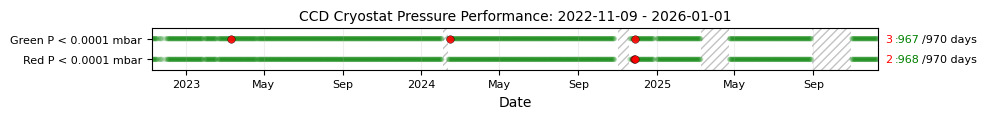

In [6]:
date_ranges = [
    (datetime(2022, 11,  9),  datetime(2026,  1,  1), 'All KPF Eras', 'kpfera_all'),
#    (datetime(2022, 11,  9),  datetime(2024,  2,  3), 'KPF Era 1.0', 'kpfera_1_0'),
#    (datetime(2024,  2, 23),  datetime(2024, 11,  1), 'KPF Era 2.0', 'kpfera_2_0'),
#    (datetime(2024, 11, 26),  datetime(2025,  3, 28), 'KPF Era 2.6', 'kpfera_2_6'),
#    (datetime(2025,  4, 23),  datetime(2025,  8, 29), 'KPF Era 3.0', 'kpfera_3_0'),
#    (datetime(2025, 10, 30),  datetime(2026,  1,  1), 'KPF Era 4.0', 'kpfera_4_0'),
]
spec_config = [
    {
        "name": "Green P < 0.0001 mbar",
        "cols": ["kpfgreen.COL_PRESS", "kpfgreen.ECH_PRESS"],
        "bool_expr": "(max(c0,c1)*1.333 > 0.0001)",  # for failure
    },
    {
        "name": "Red P < 0.0001 mbar",
        "cols": ["kpfred.COL_PRESS", "kpfred.ECH_PRESS"],
        "bool_expr": "(max(c0,c1)*1.333 > 0.0001)",  # for failure
    }
]

for start_date, end_date, era_name, fig_path_stub in date_ranges:
    columns_to_display = list(dict.fromkeys(['datecode'] + [c for spec in spec_config for c in spec['cols']]))
    df = myTS.db.dataframe_from_db(start_date=start_date, end_date=end_date, columns=columns_to_display)
    plot_title = f'CCD Cryostat Pressure Performance: {start_date.strftime("%Y-%m-%d")} - {end_date.strftime("%Y-%m-%d")}'
    fig_path = f'{plot_dir}/ccd_pressure_{fig_path_stub}.png'
    summary_by_datecode = myTS.performance_by_datecode(df, spec_config)
    myTS.plot_performance_by_datecode(summary_by_datecode, spec_config, datecode_col='datecode', plot_title=plot_title, show_plot=True)